In [ ]:
# Paste all of this code into a single cell in your SageMath Jupyter Notebook

from sage.all import Graph, QQ, Integer
import numpy as np
import itertools
import time

# --- Spectral Invariants Functions ---

def display_spectral_invariants(G):
    """
    Prints a summary of key spectral invariants for a given Sagemath graph G.
    """
    print(f"----- Spectral Invariants -----")
    
    # 1. Basic Properties
    n = G.order()
    m = G.size()
    print(f"Vertices (n): {n}")
    print(f"Edges (m):    {m}")

    if n == 0:
        print("Graph is empty.")
        print(f"------------------------------------")
        return

    # 2. Get Spectrum (list of eigenvalues)
    try:
        spec = G.spectrum()
    except Exception as e:
        print(f"Could not compute spectrum: {e}")
        print(f"------------------------------------")
        return

    # 3. Trace (Sum of eigenvalues)
    # This is always 0 for the adjacency matrix of a simple graph
    trace = sum(spec)
    print(f"Trace (sum(λi)): {float(trace):.4f}")

    # 4. Number of triangles (from trace of A^3)
    # (1/6) * sum(λi^3)
    try:
        num_triangles = Integer(round(sum(val**3 for val in spec) / 6))
        print(f"Number of Triangles: {num_triangles}")
    except TypeError:
        print("Number of Triangles: N/A (complex eigenvalues)")


    # 5. Number of 4-cycles (from A^4)
    # (1/8) * [sum(λi^4) - 2m - sum(deg_i^2)]
    # This is more complex, so we'll stick to simpler invariants.
    
    # 6. Number of closed walks of length k (sum(λi^k))
    try:
        walks_3 = Integer(round(sum(val**3 for val in spec)))
        print(f"Closed walks (k=3): {walks_3}") # Should be 6 * num_triangles
    except TypeError:
        print("Closed walks (k=3): N/A (complex eigenvalues)")

    # 7. Graph Energy
    # Sum of the absolute values of the eigenvalues
    try:
        energy = sum(abs(val) for val in spec)
        print(f"Graph Energy (sum|λi|):     {float(energy):.4f}")
    except TypeError:
         print(f"Graph Energy (sum|λi|):     N/A (complex eigenvalues)")


    # 8. Eigenvalue Spread
    max_eig = spec[-1] # spectrum() returns sorted list
    min_eig = spec[0]
    # Convert to float for formatting
    print(f"Largest Eigenvalue (λ_max): {float(max_eig):.4f}")
    print(f"Smallest Eigenvalue (λ_min): {float(min_eig):.4f}")
    
    # 9. Spectrum with Multiplicities (Refactored)
    print("\nSpectrum (with Multiplicities):")
    formatted_spec_list = get_spectrum_with_multiplicities(spec)
    print("[" + ",\n  ".join(formatted_spec_list) , "]")
    
    print(f"------------------------------------")


def get_spectrum_with_multiplicities(spec):
    """
    Takes a sorted list of eigenvalues and returns a list of strings 
    showing each unique eigenvalue and its multiplicity.
    """
    formatted_spec = []
    if not spec:
        return ["  (empty)"]

    # Use a precision for grouping floats, 5 decimal places is usually good
    precision = 5 
    
    # Convert all to float and round them
    try:
        rounded_spec = [round(float(v), precision) for v in spec]
    except TypeError:
        return ["  Could not format spectrum (complex eigenvalues?)."]

    current_val = rounded_spec[0]
    current_count = 0
    
    # Iterate through the sorted list and count occurrences
    for val in rounded_spec:
        if val == current_val:
            current_count += 1
        else:
            # When the value changes, add the previous one to our list
            formatted_spec.append(f"({current_val} : {current_count})")
            current_val = val
            current_count = 1
            
    # Add the final value and its count
    formatted_spec.append(f"({current_val} : {current_count})")
    
    return formatted_spec


# --- Graph Utilities ---

def get_spectrum(G):
    """
    Returns the spectrum of a graph as a sorted NumPy array of floats.
    """
    # G.spectrum() returns sorted list of AlgebraicReals (or floats)
    # Convert to float for numerical comparison
    try:
        spectrum_list = [float(val) for val in G.spectrum()]
        return np.array(spectrum_list)
    except Exception:
        print("Warning: Could not convert spectrum to floats. Comparing symbolic values.")
        return G.spectrum()


def is_regular(G):
    """
    Checks if a graph G is regular. Returns (bool, degree).
    """
    if G.order() == 0:
        return (True, 0)
    
    degrees = G.degree()
    if not degrees:
        return (True, 0)
        
    d = degrees[0]
    if all(deg == d for deg in degrees):
        return (True, d)
    else:
        return (False, -1)


def is_gm_partition_valid(G, C, P, k):
    """
    Checks if the partition (C, P) satisfies the Godsil-McKay conditions.
    G must be k-regular.
    C: The set of "coclique" vertices (must be an independent set)
    P: The "pivot" set
    
    Conditions:
    1. C must be an independent set.
    2. Every vertex v in P must be adjacent to k/2 vertices in C.
    """
    
    # Condition 1: Check if C is an independent set
    for u, v in itertools.combinations(C, 2):
        if G.has_edge(u, v):
            return False # C is not an independent set
            
    # Condition 2: Check pivot neighbors
    target_degree = k / 2.0
    
    # Pre-build a set for fast lookup
    C_set = set(C) 
    
    for v in P:
        neighbor_count_in_C = 0
        for neighbor in G.neighbors(v):
            if neighbor in C_set:
                neighbor_count_in_C += 1
                
        if neighbor_count_in_C != target_degree:
            return False # Fails condition 2
            
    return True


# --- Core DS Heuristic Logic ---

def find_gm_switching_partitions(G):
    """
    Generator function to find all valid Godsil-McKay partitions (C, P).
    This is a heuristic search and may not be exhaustive for all G.
    It searches for a regular G.
    """
    n = G.order()
    is_reg, k = is_regular(G)
    
    if not is_reg or k % 2 != 0:
        # GM switching as defined here requires a regular graph with even degree
        # print("Graph is not regular or has odd degree. Skipping GM-switching.")
        return

    # We are looking for a partition V = C U P U Q
    # This implementation simplifies by finding a valid (C, P) pair.
    
    vertices = list(G.vertices())
    
    # This is a brute-force search, optimized slightly.
    # It checks all pairs (i, j) to form a pivot set P = {i, j}
    # Then it finds the common non-neighbors for C.
    
    for i in range(n):
        for j in range(i + 1, n):
            P = [vertices[i], vertices[j]]
            
            # Find common non-neighbors of P
            # This is a heuristic guess for C.
            # A more robust search would check all independent sets.
            C = []
            
            # Get neighbors of i and j
            Ni = set(G.neighbors(vertices[i]))
            Nj = set(G.neighbors(vertices[j]))
            
            for l in range(n):
                v_l = vertices[l]
                if v_l not in P and v_l not in Ni and v_l not in Nj:
                    C.append(v_l)

            if not C:
                continue

            # Now, check if this partition (C, P) is valid
            if is_gm_partition_valid(G, C, P, k):
                # We found one!
                yield {'C': list(C), 'P': list(P)}


def perform_gm_switching(G, partition):
    """
    Performs the GM switch on G based on the given partition.
    
    Switching rule:
    For every v in P, swap its neighbors in C with its non-neighbors in C.
    """
    C = partition['C']
    P = partition['P']
    
    G_prime = G.copy()
    
    C_set = set(C)
    
    for v in P:
        neighbors_in_C = set()
        non_neighbors_in_C = set()
        
        for neighbor in G_prime.neighbors(v):
            if neighbor in C_set:
                neighbors_in_C.add(neighbor)
        
        non_neighbors_in_C = C_set - neighbors_in_C
        
        # Perform the swap:
        # 1. Delete edges (v, c) for c in neighbors_in_C
        G_prime.delete_edges([(v, c) for c in neighbors_in_C])
        
        # 2. Add edges (v, c) for c in non_neighbors_in_C
        G_prime.add_edges([(v, c) for c in non_neighbors_in_C])
    
    return G_prime


def check_ds_heuristic(G):
    """
    Main heuristic function.
    Tries to find a non-isomorphic, cospectral graph using GM switching.
    
    Returns: (is_not_ds, evidence_graph)
    - (True, G_prime): If a cospectral mate G_prime was found.
    - (False, None): If the search completed without finding one.
    """
    start_time = time.time()
    
    if G.order() == 0:
        print("Graph is empty.")
        return (False, None)
        
    try:
        original_spectrum = get_spectrum(G)
    except Exception as e:
        print(f"Cannot run heuristic: Failed to get spectrum. Error: {e}")
        return (False, None)

    # GM switching requires a regular graph
    is_reg, k = is_regular(G)
    if not is_reg:
        print("Heuristic check: Graph is not regular. GM-switching not applicable.")
        print("Heuristic suggests: MAY BE DS (by this method).")
        return (False, None)
    if k % 2 != 0:
        print("Heuristic check: Graph is regular but has odd degree. GM-switching not applicable.")
        print("Heuristic suggests: MAY BE DS (by this method).")
        return (False, None)
        
    print(f"Graph is {k}-regular. Searching for Godsil-McKay switching partitions...")
    
    partition_generator = find_gm_switching_partitions(G)
    found_partitions_count = 0

    for partition in partition_generator:
        found_partitions_count += 1
        
        # 1. Perform the switch
        G_prime = perform_gm_switching(G, partition)
        
        # 2. Check if the new graph is isomorphic to the original
        if not G.is_isomorphic(G_prime):
            # 3. If not isomorphic, check if it's cospectral
            new_spectrum = get_spectrum(G_prime)
            
            if np.allclose(original_spectrum, new_spectrum, atol=1e-8):
                # Success!
                end_time = time.time()
                print(f"Success! Found a non-isomorphic cospectral mate.")
                print(f"Checked {found_partitions_count} partitions in {end_time - start_time:.2f}s.")
                return (True, G_prime)

    end_time = time.time()
    print(f"Search complete. Checked {found_partitions_count} potential partitions in {end_time - start_time:.2f}s.")
    print("No non-isomorphic cospectral mates found via this method.")
    print("Heuristic suggests: The graph MAY BE DS.")
    return (False, None)



In [ ]:
analyze_graph(construct_Gn(5))

Heuristic check: Graph is not regular. GM-switching not applicable.
Heuristic suggests: MAY BE DS (by this method).

----- Heuristic Results -----
Heuristic suggests: The graph MAY BE DS.
-----------------------------
----- Spectral Invariants -----
Vertices (n): 52
Edges (m):    1227
Trace (sum(λi)): 0.0000
Number of Triangles: N/A (complex eigenvalues)
Closed walks (k=3): N/A (complex eigenvalues)
Graph Energy (sum|λi|):     100.4365
Largest Eigenvalue (λ_max): -1.6180
Smallest Eigenvalue (λ_min): 49.0008

Spectrum (with Multiplicities):
[  (49.00082 : 1),
  (0.61803 : 1),
  (0.5994 : 1),
  (-1.0 : 47),
  (-1.60022 : 1),
  (-1.61803 : 1) ]
------------------------------------


In [ ]:
def spect(G) :
    spct = tuple(sorted([round(val, 4) for val in G.spectrum()]))
    return spct

In [ ]:
# Import the time library to track how long the search takes
import time

# --- Step 1: Define the graph G you want to test ---
# Use one of the examples from our previous discussion
# G = Graph([(0,1), (0,2), (0,3), (0,4), (0,5), (1,2), (3,4)]) # 6-vertex non-DS graph
G = graphs.CycleGraph(5) # 5-vertex DS graph

def is_ds(G) :
    A = G.adjacency_matrix()
    # Diplay the graphs
    # G.show()

    count = 0
    spec = spect(G)
    deg = G.degree_sequence()
    n = G.order()
    e = G.size()
    t = G.triangles_count()
    walks_4 = (A**4).trace()

    # Itrete all graphs or n vertices and m edges
    # for H in graphs(n) :
    m=e
    c = 0
    tg = 0
    candidates = []
    for H in graphs.nauty_geng(f"{n} -c {m}:{m}") :
        c = c+1
        B = H.adjacency_matrix()
        # print("'", end="")
        tg = tg+1
        # if e != H.size() :
        #     continue
        # if deg != H.degree_sequence() :
        #     continue
        #if t != H.triangles_count() :
        #    continue
        #if walks_4 != (B**4).trace() :
        #    continue
        if spect(H) != spec :
            continue
        count = count + 1
        
        print("check :")
        H.show()
        #candidates.append(H)
        #print(H.edges(labels=False))
        #print("spectrun of H : ", spect(H))
        #print("Are they isomorphic?", H.is_isomorphic(G))
        print("-------------------------------------------")

    #print(count)
    #print(c)

    if count == 1 :
        print(f"G -> is DS!")
    elif count == 0 :
        print("error!")
    else :
        print(f"G have {count-1} cospectral mates candidate. varify If they are non isometric.")
    
    end_time = time.time()
    print("total graphch checked : ", tg)
    """
    # print("Count = " , count)
    if count == 1 :
        print("\nRESULT: No non-isomorphic cospectral mates were found.")
        #print("This provides strong computational evidence that G is Determined by its Spectrum (DS).")
        print(f"K{n-1} + pendent -> is DS!")

    else :
        print(f"Search complete. Generated {total_graphs_generated} graphs in {end_time - start_time:.2f} seconds.")
        print(f"Found {len(candidates)} candidate(s) that passed all filters.\n")


    # --- Step 4: Final verification and reporting ---
        cospectral_mates = []
        if candidates:
            print("--- Verifying Full Spectra of Candidates ---")
            for H in candidates:
                h_spec = tuple(sorted([round(val, 6) for val in H.spectrum()]))
                
                # FINAL CHECK: Compare the full spectra to confirm cospectrality
                if g_spec == h_spec:
                    cospectral_mates.append(H)
                    #print("-------------------------------------------")
                    print("CONFIRMED Non-Isomorphic Cospectral Mate Found!")
                    print("Edges:", H.edges(labels=False))
                    #H.show()
                    #print(f"  - H Spectrum: {h_spec}")
                    print("-------------------------------------------")
        print(f"\nRESULT: Found {len(cospectral_mates) - 1} cospectral mate(s). G is NOT DS.")
   """
        



In [ ]:
import networkx as nx
import numpy as np
import collections

def construct_Gn(n):
    """
    Constructs the graph G_n: a complete graph K_n with two pendant
    vertices attached to two different vertices of K_n.
    
    Here, we attach them to nodes 0 and 1.
    """
    if n < 2:
        raise ValueError("n must be at least 2 for G_n to be well-defined.")
        
    # 1. Create the complete graph K_n on nodes 0 to n-1
    G = graphs.CompleteGraph(n)
    
    # 2. Add the two new pendant vertices
    
    for i in range(0, 2) :
        G.add_vertex(n+i)
        G.add_edge(i, n+i)

    return G

K8 + two pendent vertices : DS check ->
check :


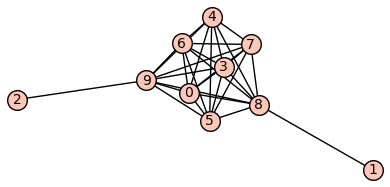

-------------------------------------------
G -> is DS!
total graphch checked :  136370
finished!


In [ ]:
n=8
for n in range(n,n+1) :
    gn = construct_Gn(n)
    print(f"K{n} + two pendent vertices : DS check ->")
    #gn.show()
    is_ds(gn)
    #gn.show()
    print ("======================================================================================")
print("finished!")

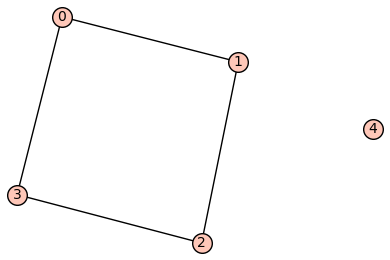

check :


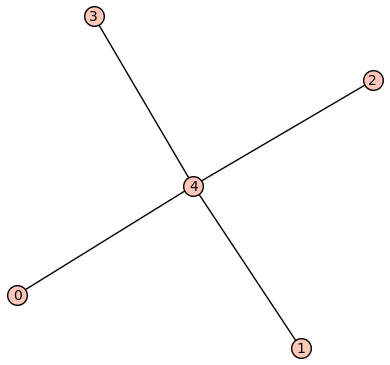

-------------------------------------------
G -> is DS!
total graphch checked :  3


In [ ]:
X = graphs.CycleGraph(4)
X.add_vertex(4)
X.show()
is_ds(X)


In [ ]:

# --- Example of how to use the function in a new cell ---
def analyze_graph(G) :
    # 1. Assume you have your graph in a variable.
    #    (I'll use the Shrikhande graph as an example)
    my_graph = G  # <--- REPLACE THIS with your graph

    # 2. Run the heuristic function on it
    is_not_ds, evidence_graph = check_ds_heuristic(my_graph)

    # 3. Print the results
    print("\n----- Heuristic Results -----")
    if is_not_ds:
        print(f"Strong evidence: The graph is NOT Determined by its Spectrum (DS).")
        # You can show the new graph in the notebook:
        # print("The new cospectral, non-isomorphic graph:")
        # evidence_graph.show()
    else:
        print(f"Heuristic suggests: The graph MAY BE DS.")
    print("-----------------------------")
    display_spectral_invariants(gn)

In [ ]:
analyze_graph(construct_Gn(50))


>>> Running DS Heuristic Check <<<
Analyzing graph with 52 vertices and 1227 edges.
Searching for Godsil-McKay switching partitions...
Search complete. Checked 0 potential partitions.

----- Heuristic Results -----
Heuristic suggests: The graph MAY BE DS.
-----------------------------

--- Spectral Invariants for Graph ---
Number of vertices (n):     52
Number of edges (m):        1227
Sum of eigenvalues (tr(A)): 0
Number of triangles (tr(A^3)/6): 19600
Closed walks of length 4 (tr(A^4)): 5765246
Graph Energy (sum|λi|):     100.4364
Largest Eigenvalue (λ_max): 49.0008
Smallest Eigenvalue (λ_min): -1.6180
------------------------------------


check :


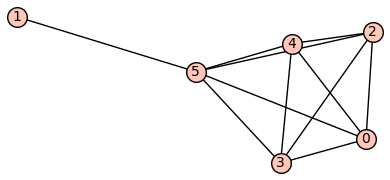

-------------------------------------------
G -> is DS!
total graphch checked :  9
check :


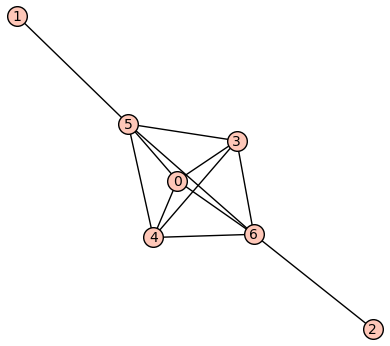

-------------------------------------------
G -> is DS!
total graphch checked :  126
check :


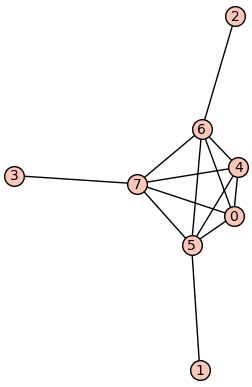

-------------------------------------------
G -> is DS!
total graphch checked :  1454


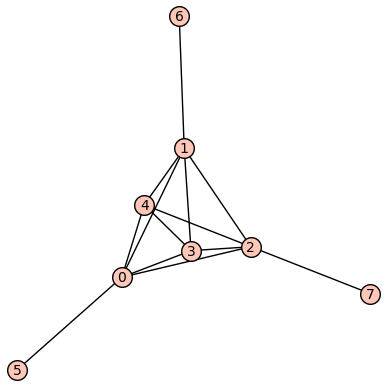

In [ ]:
n=5;
g = graphs.CompleteGraph(n)
j=0
for i in range (n, n+3) :
    g.add_vertex(i)
    g.add_edge((j, i))
    is_ds(g)
    j = j+1 
g.show()


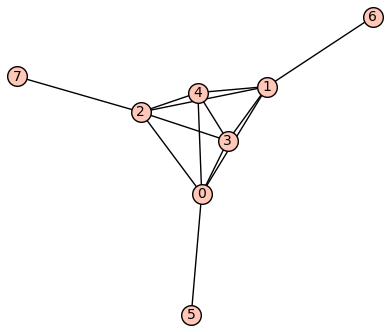

(-1.618034, -1.618034, -1.328872, -1.0, 0.181442, 0.618034, 0.618034, 4.14743)

In [ ]:
g.show()
spect(g)

check :


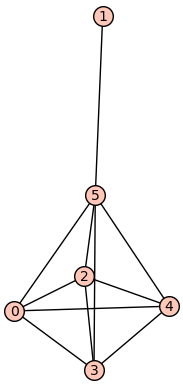

-------------------------------------------
G -> is DS!
total graphch checked :  9
check :


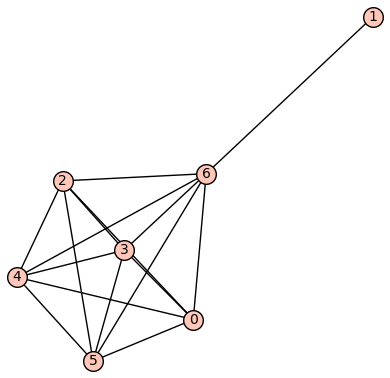

-------------------------------------------
G -> is DS!
total graphch checked :  21
check :


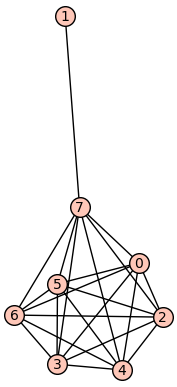

-------------------------------------------
G -> is DS!
total graphch checked :  56
check :


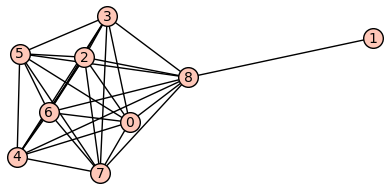

-------------------------------------------
G -> is DS!
total graphch checked :  148
check :


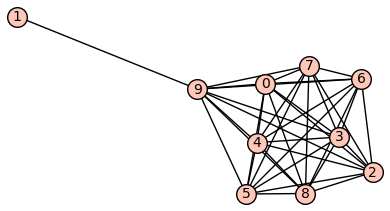

-------------------------------------------
G -> is DS!
total graphch checked :  428
check :


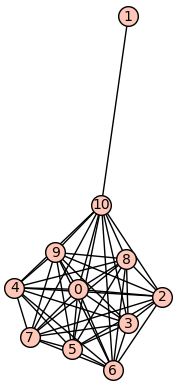

-------------------------------------------
G -> is DS!
total graphch checked :  1305


KeyboardInterrupt: 

In [ ]:
k1 = 5
k2 = 14
for n in range(k1,k2) :
    Kn = graphs.CompleteGraph(n)
    
    Kn.add_vertex(n)
    Kn.add_edge((0,n))

    G = Kn
    is_ds(G)
print("Finishe!")
    

In [ ]:
# create my graph
#my_graph_data = {0 : [1,2,6], 1 : [3,2], 2 : [4], 3 : [2], 4 : [5,6]}
# Create the grph object
#G = Graph(my_graph_data)

# Pair of cospectral graphs on 6 vertices
""" G1_edges = [(0,1), (0,2), (0,3), (0,4), (0,5), (1,2), (3,4)]
G1 = Graph(G1_edges)

G2_edges = [(0,1), (1,2), (2,3), (3,4), (5,1), (5,2), (5,3)]
G2 = Graph(G2_edges)
G = G1 """

n = 8
G = graphs.CompleteGraph(n)
G.add_vertex(n)
G.add_edge((0,n))
G.add_vertex(n+1)
for k in range(0,n) :
    print("k : ",k)
    G.add_edge((k,n+1))
    G.add_edge((n,n+1))
    is_ds(G)

#G = graphs.CycleGraph(4)
#G.add_vertex(5)
#G = graphs.StarGraph(4)

In [ ]:

A = G.adjacency_matrix()
# Diplay the graphs
G.show()

count = 0
spec = G.spectrum()
deg = G.degree_sequence()
n = G.order()
e = G.size()
t = G.triangles_count()
walks_4 = (A**4).trace()

In [ ]:
# Itrete all graphs or n vertices
# for H in graphs(n) :
m=e
c = 0
for H in graphs.nauty_geng(f"{n} -c {m}:{m}") :
    c = c+1
    B = H.adjacency_matrix()
    # if e != H.size() :
    #     continue
    # if deg != H.degree_sequence() :
    #     continue
    if t != H.triangles_count() :
        continue
    if walks_4 != (B**4).trace() :
        continue
    count = count + 1
    print(H.edges(labels=False))
    H.show()
    #print("Are they isomorphic?", H.is_isomorphic(G))
    print("-------------------------------------------")

print(count)
print(c)

In [ ]:
# The original loop:
# for H in graphs(n):

# The more efficient, focused loop:
# The string '-c' ensures we only get connected graphs.
# The arguments min_edges and max_edges restrict the search.
#for H in graphs.nauty_geng(f"{n} -c {m}:{m}"):
    #... rest of the code...

In [ ]:
if count == 1 :
    print("G is DS!")
else :
    print(f"G have {count-1} cospectral mates candidate. varify If they are non isometric.")